In [1]:
from schnetpack.md.utils import HDF5Loader
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from schnetpack.md.utils import MDUnits

%load_ext autoreload
%autoreload 2

In [20]:
data = HDF5Loader('md_logs/2022-05-19_LVfdSoNg/simulation_gpu_resorcinol_dipole_001.hdf5', load_properties=True, skip_initial=5000)

Shape: (182600, 1)
Shape: [[0.42940363]
 [0.42940286]
 [0.42940378]
 ...
 [0.42941046]
 [0.42941046]
 [0.42941046]]


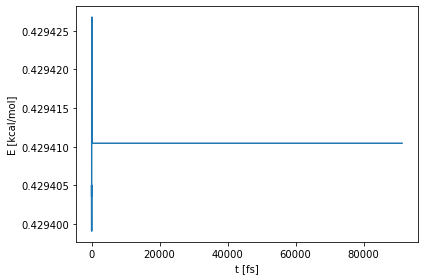

In [27]:
energies = data.get_property('energy')
print('Shape:', energies.shape)
print('Shape:', energies)

# Get the time axis
time_axis = np.arange(data.entries)*data.time_step / MDUnits.fs2internal # in fs

# Plot the energies
plt.figure()
plt.plot(time_axis, energies)
plt.ylabel('E [kcal/mol]')
plt.xlabel('t [fs]')
plt.tight_layout()
plt.show()

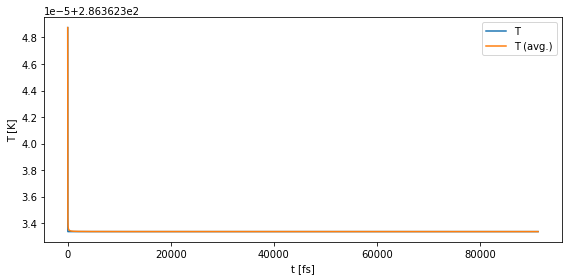

In [28]:
def plot_temperature(data):

    # Read the temperature
    temperature = data.get_temperature()

    # Compute the cumulative mean
    temperature_mean = np.cumsum(temperature) / (np.arange(data.entries)+1)

    # Get the time axis
    time_axis = np.arange(data.entries)*data.time_step / MDUnits.fs2internal # in fs

    plt.figure(figsize=(8,4))
    plt.plot(time_axis, temperature, label='T')
    plt.plot(time_axis, temperature_mean, label='T (avg.)')
    plt.ylabel('T [K]')
    plt.xlabel('t [fs]')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_temperature(data)

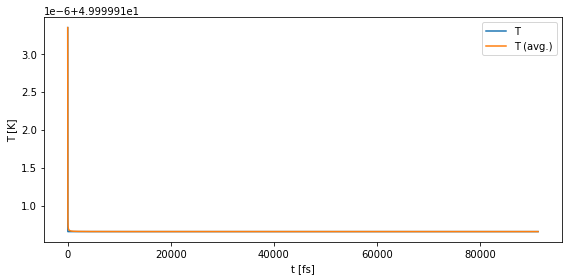

In [29]:
def plot_k_energy(data):

    # Read the k_energy
    k_energy = data.get_kinetic_energy()

    # Compute the cumulative mean
    k_energy_mean = np.cumsum(k_energy) / (np.arange(data.entries)+1)

    # Get the time axis
    time_axis = np.arange(data.entries)*data.time_step / MDUnits.fs2internal # in fs

    plt.figure(figsize=(8,4))
    plt.plot(time_axis, k_energy, label='T')
    plt.plot(time_axis, k_energy_mean, label='T (avg.)')
    plt.ylabel('T [K]')
    plt.xlabel('t [fs]')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_k_energy(data)

std potential 2.5324297e-07
std kinetic 2.4601936293434285e-09
energy_unit 0.010364269574711572
kcal 2.5196637345688e+24
kJ 6.022140857000001e+23
ha 2625.4996387552483


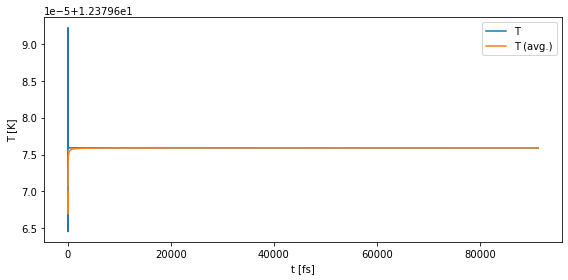

In [30]:
def plot_total_energy(data):

    # Read the k_energy
    k_energy = data.get_kinetic_energy() *  MDUnits.conversions['kj']/MDUnits.conversions['kcal']
    p_energy = data.get_property('energy').squeeze()
    print('std potential', np.std(p_energy))
    print('std kinetic', np.std(k_energy))
    print('energy_unit', MDUnits.energy_unit)
    print('kcal', MDUnits.conversions['kcal'])
    print('kJ', MDUnits.conversions['kj'])
    print('ha', MDUnits.conversions['ha'])
    total_energy = k_energy + p_energy

    # Compute the cumulative mean
    total_energy_mean = np.cumsum(total_energy) / (np.arange(data.entries)+1)

    # Get the time axis
    time_axis = np.arange(data.entries)*data.time_step / MDUnits.fs2internal # in fs

    plt.figure(figsize=(8,4))
    plt.plot(time_axis, total_energy, label='T')
    plt.plot(time_axis, total_energy_mean, label='T (avg.)')
    plt.ylabel('T [K]')
    plt.xlabel('t [fs]')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_total_energy(data)

/home/mihail/Documents/workspace/schnetpack/src/schnetpack/md/utils/spectra.py:46: RuntimeWarning: invalid value encountered in true_divide
  data = (data - np.mean(data)) / np.std(data)


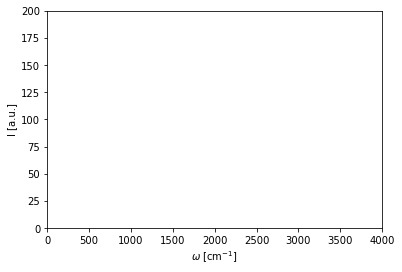

In [31]:
from schnetpack.md.utils.spectra import PowerSpectrum

spectrum = PowerSpectrum(data, resolution=4096)

spectrum.compute_spectrum(molecule_idx=0)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,200)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.show()



/home/mihail/Documents/workspace/schnetpack/src/schnetpack/md/utils/spectra.py:46: RuntimeWarning: invalid value encountered in true_divide
  data = (data - np.mean(data)) / np.std(data)


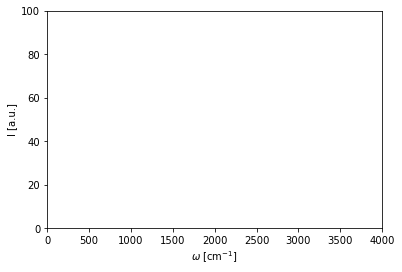

In [8]:
from schnetpack.md.utils.spectra import PowerSpectrum

spectrum = PowerSpectrum(data, resolution=4096)

spectrum.compute_spectrum(molecule_idx=0)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,100)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.show()



/home/mihail/Documents/workspace/schnetpack/src/schnetpack/md/utils/spectra.py:46: RuntimeWarning: invalid value encountered in true_divide
  data = (data - np.mean(data)) / np.std(data)


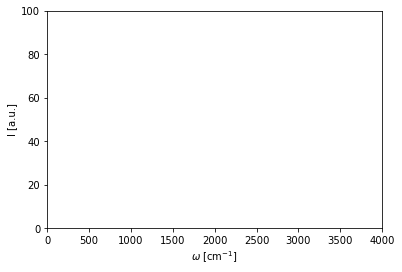

In [33]:
from schnetpack.md.utils.spectra import PowerSpectrum

spectrum = PowerSpectrum(data, resolution=4096)

spectrum.compute_spectrum(molecule_idx=0)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,100)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')


#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/ml_ethanol_vib_spectrum.svg')
plt.show()

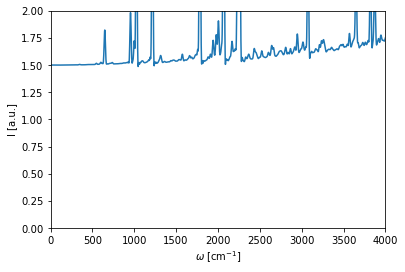

In [34]:
from schnetpack.md.utils.spectra import IRSpectrum

spectrum = IRSpectrum(data, dipole_moment_handle='dipole_moment', resolution=4096)

spectrum.compute_spectrum(molecule_idx=0)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,2)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/ml_ethanol_IR_spectrum.svg')
plt.show()

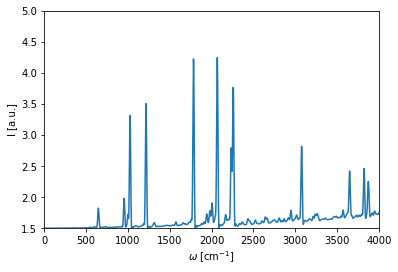

In [39]:
from schnetpack.md.utils.spectra import IRSpectrum

spectrum = IRSpectrum(data, dipole_moment_handle='dipole_moment', resolution=4096)

spectrum.compute_spectrum(molecule_idx=0)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(1.5, 5)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/nat_manuscript/figures/ml_ethanol_IR_spectrum.svg')
plt.show()


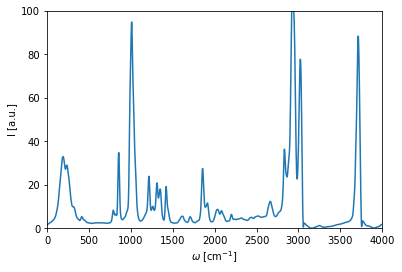

In [42]:
from schnetpack.md.utils.spectra import IRSpectrum

spectrum = IRSpectrum(data, dipole_moment_handle='dipole_moment', resolution=4096)

spectrum.compute_spectrum(molecule_idx=3)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,100)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/ml_ethanol_IR_spectrum_3.svg')
plt.show()


In [18]:
from schnetpack.md.utils.spectra import fft_autocorrelation
dpm = data.get_property('dipole_moment')
print(dpm.shape)
autocorr = np.zeros((3, dpm.shape[0] - 1))
for i in range(dpm.shape[1]):
    print('i', i)
    autocorr[i] = fft_autocorrelation(dpm[:, i], dpm.shape[0] - 2)

print(autocorr.shape)

(200000, 3)
i 0
i 1
i 2
(3, 199999)


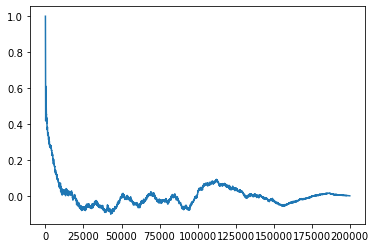

In [19]:
import matplotlib.pyplot as plt

plt.plot(np.mean(autocorr, axis=0))

#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/autocorrelation.svg')
plt.show()

[[ -7.648527    8.224964    6.5621133]
 [-11.796831   12.331962    6.8140025]
 [-13.459861    7.822513   10.413288 ]
 ...
 [ -3.651142    0.9157657 -17.133713 ]
 [ -3.781229   -4.9688816  -6.9968696]
 [ -0.7128417   1.5041827 -10.929107 ]]
i 0
i 1
i 2
(3, 199998)


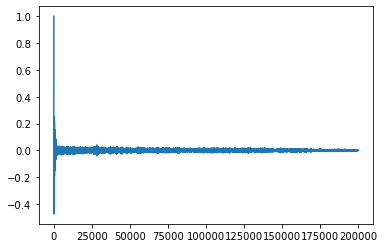

In [20]:
h = 0.5 / 1000

diff = np.diff(dpm, axis=0)
diff = diff/h
print(diff)

autocorr = np.zeros((3, diff.shape[0] - 1))
for i in range(diff.shape[1]):
    print('i', i)
    autocorr[i] = fft_autocorrelation(diff[:, i], diff.shape[0] - 2)
    
print(autocorr.shape)
plt.plot(np.mean(autocorr, axis=0))

#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/diff_autocorrelation.svg')
plt.show()